# Chapter 2: Manifolds

**Source Span.** `An Introduction to Manifolds.pdf`, printed pages `48-85` (PDF pages `67-104`). The revision read the chapter span covering topological manifolds, compatible charts, smooth atlases, smooth maps, diffeomorphisms, component tests, Lie groups as examples, quotient topology, Hausdorff quotient warnings, open equivalence relations, real projective space, and the standard smooth atlas on projective space.

**Chapter Goal.** Learn to recognize when a space deserves coordinates, when coordinate changes are smooth, and when a quotient construction still behaves like a manifold. The chapter is the bridge from Euclidean calculation to intrinsic geometry: every definition is checked by pulling it through charts, and every warning is a reminder that local Euclidean pictures do not automatically give a good global space.

The notebook builds four inspection surfaces. A circle atlas shows compatibility through transition maps. A chart expression shows how smoothness is tested without leaving the manifold. A quotient failure diagram separates local Euclidean behavior from the Hausdorff condition. Projective coordinates then show a successful quotient, where antipodal lines are represented by compatible affine charts. The examples are original computational models and do not reproduce textbook figures or exercise text.

## Visual Storyboard

1. **Circle atlas transition.** Two stereographic charts on `S^1` overlap away from the excluded poles. Inspection target: the transition `u -> 1/u` is smooth on each overlap component, so the atlas is compatible even though no one chart sees all of the circle.
2. **Smoothness through charts.** A smooth function on the circle is rewritten as an ordinary function of a chart coordinate. Inspection target: chart expressions are rational/trigonometric formulas on open subsets of `R`, which is the local test used in the definition.
3. **Quotients can fail Hausdorff.** A line with two origins model shows two distinct origin classes that every small neighborhood must approach through the same punctured line. Inspection target: local coordinates are not enough; Hausdorff and second countability are part of the manifold definition.
4. **Projective space as a successful quotient.** `RP^1` is the antipodal quotient of `S^1`; its standard charts use slopes where one homogeneous coordinate is nonzero. Inspection target: antipodal representatives give the same slope, and chart transitions are smooth reciprocal maps.

## Library Routing

| Chapter concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| Compatible charts | stereographic circle atlas with transition plot | SymPy, NumPy, Matplotlib | charts are functions, but overlap geometry benefits from a picture |
| Smooth maps | chart-coordinate expression and derivative check | SymPy, Matplotlib | the definition reduces manifold smoothness to Euclidean smoothness |
| Bad quotients | neighborhood intersection diagram | NetworkX-free Matplotlib primitives | the Hausdorff failure is topological and best seen as neighborhoods |
| Real projective space | antipodal quotient and slope charts | NumPy, SymPy, Matplotlib | projective equivalence is visual and algebraic at the same time |

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-02-manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ARTIFACT_ROOT / "figures"
CHECK = ARTIFACT_ROOT / "checks"
TABLE = ARTIFACT_ROOT / "tables"
created_artifacts = []

def keep(path):
    created_artifacts.append(Path(path))
    return path

print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifacts: artifacts\chapter-02-manifolds


## Translation Guide

A topological manifold is not just a set with coordinates. It must be locally Euclidean, Hausdorff, and second countable. The local Euclidean condition says every point has a coordinate neighborhood. Hausdorffness says distinct points can be separated by neighborhoods. Second countability prevents pathological spaces with too many incompatible local pieces. The smooth structure is extra data: an atlas whose chart transitions are smooth on overlaps, enlarged to a maximal compatible atlas.

The definition of a smooth map is deliberately local. A map between manifolds is smooth when, after choosing charts in the source and target, it becomes a smooth map between open subsets of Euclidean spaces. This is why compatible atlases matter: the answer should not depend on the chart chosen. Diffeomorphisms are the isomorphisms of this category; they preserve the smooth structure in both directions.

Quotients are the chapter's useful danger zone. They create spaces by identifying points, which is exactly how projective spaces arise, but they can also destroy Hausdorffness. The right computational habit is to track equivalence classes, quotient maps, and chart domains together. Projective space succeeds because the standard slope charts are compatible and cover the quotient by nonzero homogeneous coordinates.

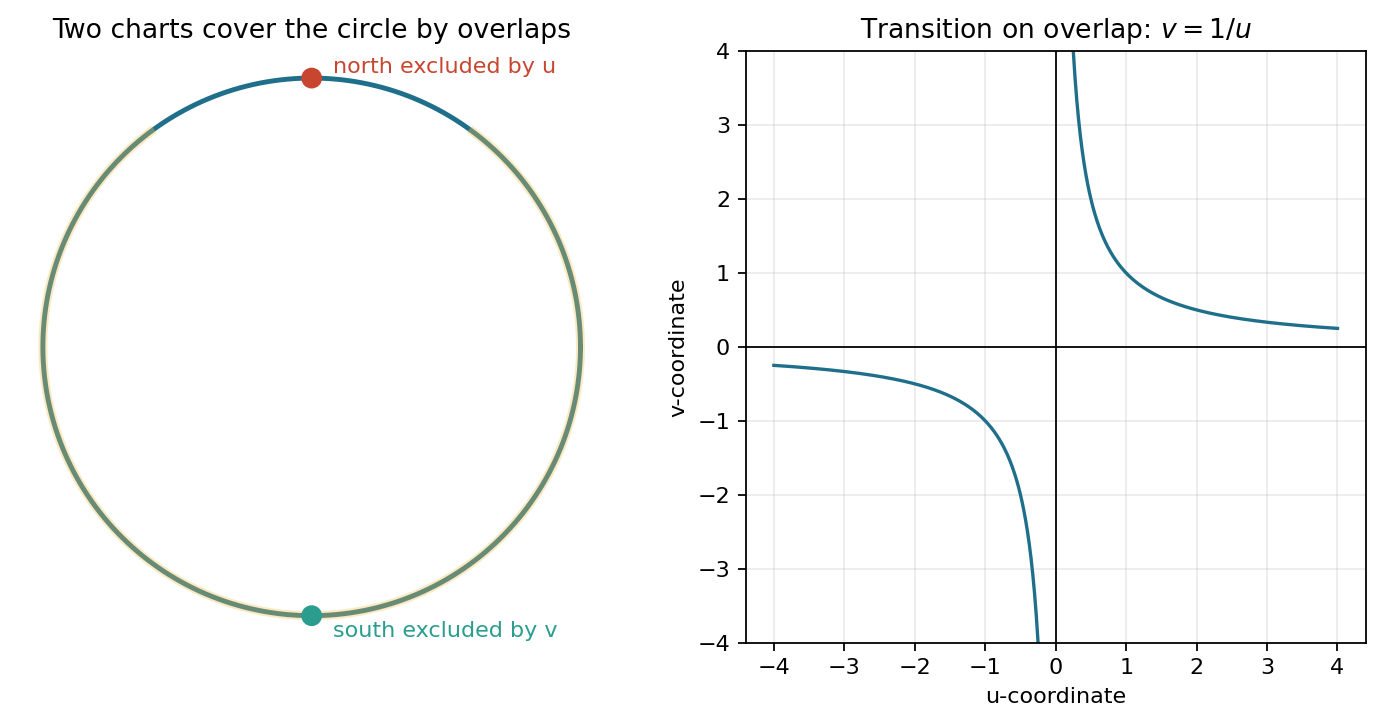

{'transition_v_of_u': '1/u',
 'transition_derivative': '-1/u**2',
 'smooth_on_overlap_components': True,
 'excluded_transition_point': 'u=0 corresponds to the south pole, not in the overlap'}

In [2]:
# Stereographic charts on S^1: from north and south poles.
u = sp.symbols("u", real=True, nonzero=True)
x_from_u = 2*u / (1 + u**2)
y_from_u = (u**2 - 1) / (1 + u**2)
v_transition = sp.simplify(x_from_u / (1 + y_from_u))
transition_derivative = sp.diff(v_transition, u)

u_vals_left = np.linspace(-4.0, -0.25, 300)
u_vals_right = np.linspace(0.25, 4.0, 300)
theta = np.linspace(0, 2*np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(np.cos(theta), np.sin(theta), color="#1f6f8b", lw=2.2)
axes[0].scatter([0, 0], [1, -1], color=["#c84630", "#2a9d8f"], s=70, zorder=3)
axes[0].text(0.08, 1.02, "north excluded by u", color="#c84630")
axes[0].text(0.08, -1.08, "south excluded by v", color="#2a9d8f")
u_cover = np.linspace(-3, 3, 300)
x_cover = 2*u_cover / (1 + u_cover**2)
y_cover = (u_cover**2 - 1) / (1 + u_cover**2)
axes[0].plot(x_cover, y_cover, color="#f2c14e", lw=4, alpha=0.35, label="u-chart coverage")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Two charts cover the circle by overlaps")
axes[0].axis("off")
axes[1].plot(u_vals_left, 1/u_vals_left, color="#1f6f8b")
axes[1].plot(u_vals_right, 1/u_vals_right, color="#1f6f8b")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_ylim(-4, 4)
axes[1].set_title(r"Transition on overlap: $v=1/u$")
axes[1].set_xlabel("u-coordinate")
axes[1].set_ylabel("v-coordinate")
axes[1].grid(alpha=0.25)
atlas_path = keep(save_matplotlib(fig, FIG / "circle-atlas-transition.png"))
plt.close(fig)
atlas_check = {
    "transition_v_of_u": str(v_transition),
    "transition_derivative": str(transition_derivative),
    "smooth_on_overlap_components": True,
    "excluded_transition_point": "u=0 corresponds to the south pole, not in the overlap",
}
atlas_check_path = keep(save_json(atlas_check, CHECK / "circle-atlas-transition-check.json"))
display_artifact(atlas_path, width=820)
atlas_check

## Smooth Maps Are Checked in Coordinates

A smooth real-valued function on a manifold is smooth when its expression in every coordinate chart is smooth. For the circle, a function such as `h(x,y)=x^2+y` becomes a one-variable formula after substituting the chart parametrization. This is the local test behind the chapter's propositions about smoothness in terms of charts and components.

The same principle governs maps between manifolds: choose a chart around the source point and a chart around the target point, write the coordinate representation, and test it as an ordinary Euclidean map. The computational point is not that every formula should be global. It is that compatible local formulas agree on overlaps.

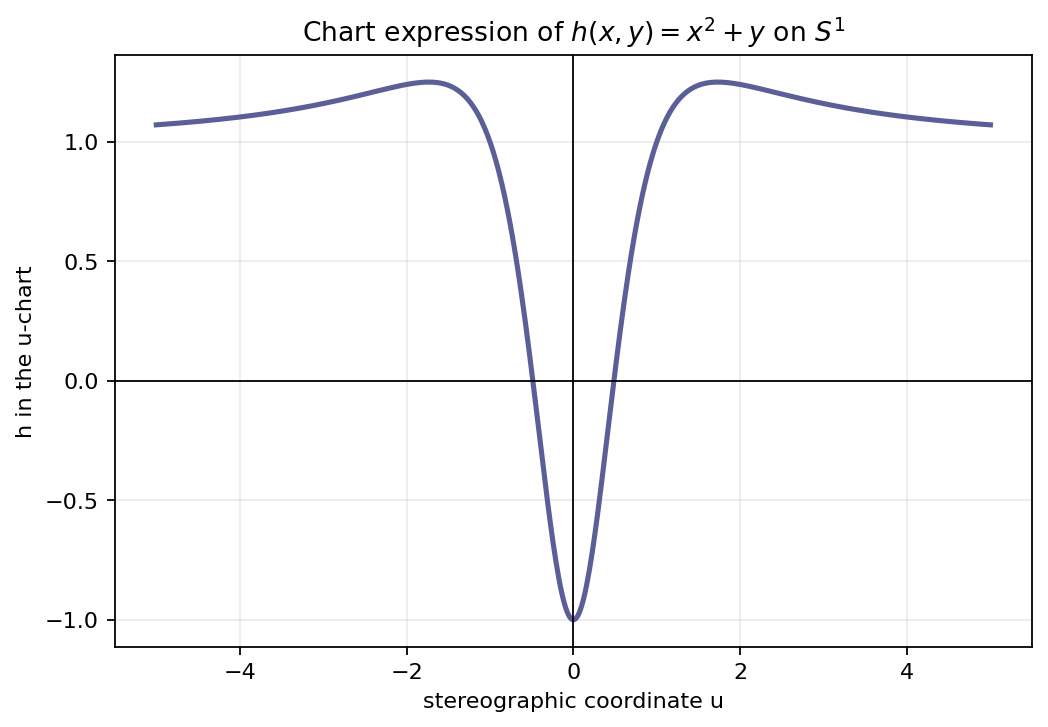

{'h_in_u_chart': '(u**4 + 4*u**2 - 1)/(u**4 + 2*u**2 + 1)',
 'derivative_in_u_chart': '-4*u*(u**2 - 3)/(u**2 + 1)**3',
 'denominator_positive': '1 + u**2',
 'coordinate_test': 'ordinary smooth rational expression on the chart domain'}

In [3]:
h_u = sp.simplify(x_from_u**2 + y_from_u)
h_u_prime = sp.factor(sp.diff(h_u, u))
u_plot = np.linspace(-5, 5, 600)
h_vals = np.array([float(h_u.subs(u, val)) for val in u_plot])
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(u_plot, h_vals, color="#5b5f97", lw=2.3)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_title(r"Chart expression of $h(x,y)=x^2+y$ on $S^1$")
ax.set_xlabel("stereographic coordinate u")
ax.set_ylabel("h in the u-chart")
ax.grid(alpha=0.25)
smooth_path = keep(save_matplotlib(fig, FIG / "chart-smoothness-expression.png"))
plt.close(fig)
smooth_check = {
    "h_in_u_chart": str(h_u),
    "derivative_in_u_chart": str(h_u_prime),
    "denominator_positive": "1 + u**2",
    "coordinate_test": "ordinary smooth rational expression on the chart domain",
}
smooth_check_path = keep(save_json(smooth_check, CHECK / "chart-smoothness-check.json"))
display_artifact(smooth_path, width=720)
smooth_check

## Quotients: Local Pictures Are Not Enough

The quotient topology is powerful because it lets us declare points equivalent and then ask which subsets downstairs have open preimages upstairs. But quotients can lose separation. A standard warning model is the line with two origins: two copies of the real line are identified away from zero, leaving two distinct origins. Each origin has neighborhoods that include punctured intervals from the same identified line, so no disjoint neighborhoods can separate them.

This is exactly why the manifold definition includes Hausdorffness. Near either origin the space still looks locally like a line, but the two origins cannot be pulled apart. The diagram below is not a textbook figure; it is a computational schematic of the equivalence relation and the forced intersection pattern.

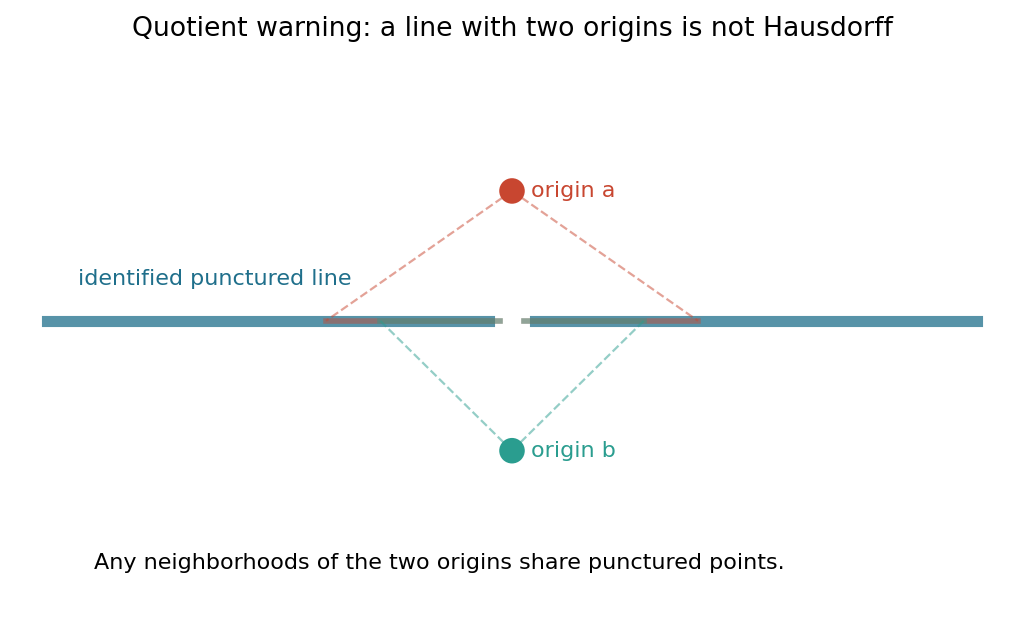

{'locally_euclidean_at_each_origin': True,
 'two_distinct_origin_classes': True,
 'hausdorff_separation_possible': False,
 'manifold_condition_failed': 'Hausdorff'}

In [4]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
# Common punctured line after identification.
ax.plot([-3, -0.15], [0, 0], color="#1f6f8b", lw=5, alpha=0.75)
ax.plot([0.15, 3], [0, 0], color="#1f6f8b", lw=5, alpha=0.75)
ax.scatter([0, 0], [0.55, -0.55], color=["#c84630", "#2a9d8f"], s=110, zorder=4)
ax.text(0.12, 0.55, "origin a", va="center", color="#c84630")
ax.text(0.12, -0.55, "origin b", va="center", color="#2a9d8f")
for radius, color, y0 in [(1.2, "#c84630", 0.55), (0.85, "#2a9d8f", -0.55)]:
    ax.plot([-radius, -0.08], [0, 0], color=color, lw=2.5, alpha=0.45)
    ax.plot([0.08, radius], [0, 0], color=color, lw=2.5, alpha=0.45)
    ax.plot([0, -radius], [y0, 0], color=color, lw=1.0, ls="--", alpha=0.5)
    ax.plot([0, radius], [y0, 0], color=color, lw=1.0, ls="--", alpha=0.5)
ax.text(-2.8, 0.15, "identified punctured line", color="#1f6f8b")
ax.text(-2.7, -1.05, "Any neighborhoods of the two origins share punctured points.", fontsize=10)
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-1.25, 1.15)
ax.axis("off")
ax.set_title("Quotient warning: a line with two origins is not Hausdorff")
quotient_path = keep(save_matplotlib(fig, FIG / "quotient-line-two-origins-hausdorff-failure.png"))
plt.close(fig)
quotient_check = {
    "locally_euclidean_at_each_origin": True,
    "two_distinct_origin_classes": True,
    "hausdorff_separation_possible": False,
    "manifold_condition_failed": "Hausdorff",
}
quotient_check_path = keep(save_json(quotient_check, CHECK / "quotient-hausdorff-warning-check.json"))
display_artifact(quotient_path, width=760)
quotient_check

## Real Projective Space and Standard Charts

Real projective space identifies nonzero vectors that differ by a nonzero scalar. For `RP^1`, that means antipodal points on the circle represent the same line through the origin. The successful atlas uses homogeneous coordinates: where `x != 0`, record slope `y/x`; where `y != 0`, record reciprocal slope `x/y`. On the overlap the transition is reciprocal, smooth away from zero.

This projective example ties several chapter themes together. It is a quotient, but unlike the line with two origins it has well-behaved standard charts. It is not presented as a subset with inherited coordinates; instead the quotient map and the chart formulas work together. The next cell checks that antipodal representatives give the same chart coordinate and that the transition formulas agree.

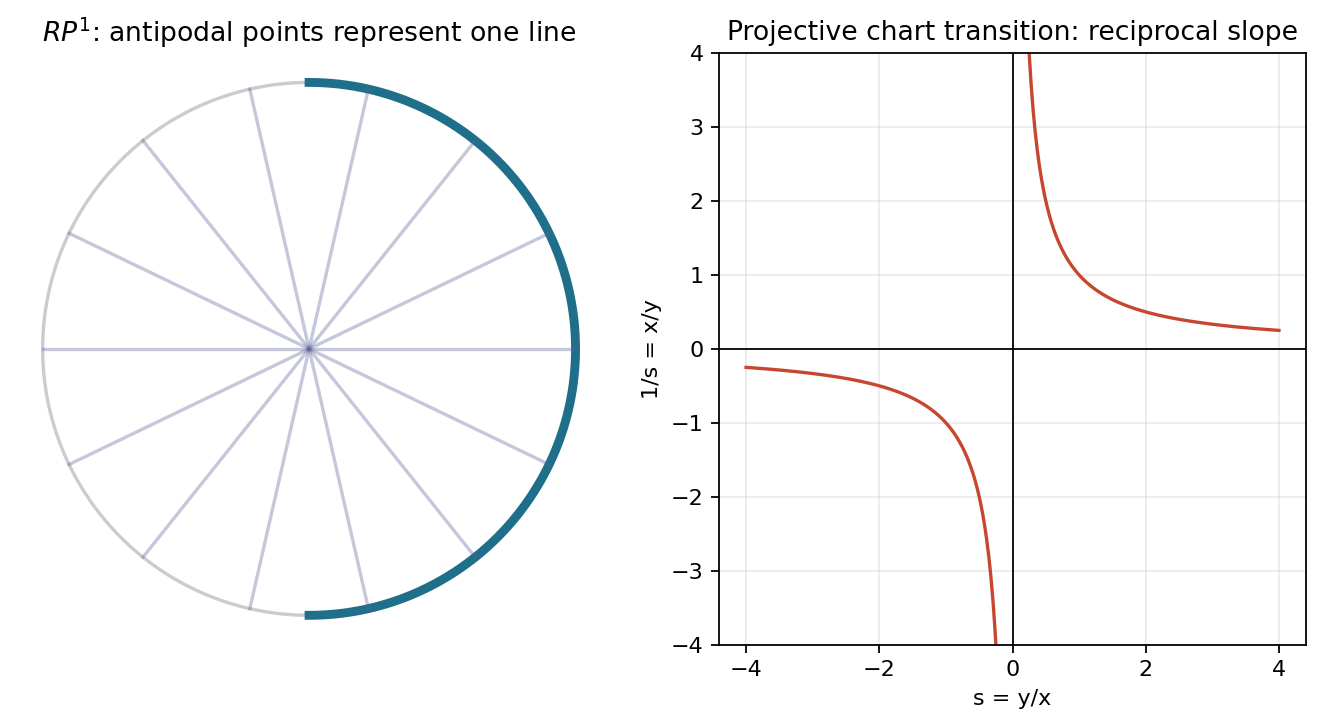

{'transition_x_chart_to_y_chart': '1/s',
 'transition_derivative': '-1/s**2',
 'antipodal_first_pair_same_slope': True,
 'antipodal_second_pair_same_slope': True}

In [5]:
angles = np.linspace(0, 2*np.pi, 400)
pts = np.column_stack([np.cos(angles), np.sin(angles)])
# choose representatives in the right half-plane for RP^1 visualization
rep_angles = np.linspace(-np.pi/2, np.pi/2, 240)
rep_pts = np.column_stack([np.cos(rep_angles), np.sin(rep_angles)])

sample_vectors = [(2.0, 1.0), (-2.0, -1.0), (1.0, -3.0), (-1.0, 3.0)]
projective_rows = []
for X, Y in sample_vectors:
    projective_rows.append({"X": X, "Y": Y, "y_over_x_if_x_nonzero": Y/X if X != 0 else None, "x_over_y_if_y_nonzero": X/Y if Y != 0 else None})

s = sp.symbols("s", real=True, nonzero=True)
transition_x_to_y = sp.simplify(1/s)
transition_derivative_rp = sp.diff(transition_x_to_y, s)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.8))
axes[0].plot(pts[:,0], pts[:,1], color="#cccccc", lw=1.5)
axes[0].plot(rep_pts[:,0], rep_pts[:,1], color="#1f6f8b", lw=4, label="chosen representatives")
for angle in np.linspace(0, np.pi, 7, endpoint=False):
    axes[0].plot([np.cos(angle), -np.cos(angle)], [np.sin(angle), -np.sin(angle)], color="#5b5f97", alpha=0.35)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title(r"$RP^1$: antipodal points represent one line")
axes[0].axis("off")
axes[1].plot(np.linspace(-4, -0.25, 250), 1/np.linspace(-4, -0.25, 250), color="#c84630")
axes[1].plot(np.linspace(0.25, 4, 250), 1/np.linspace(0.25, 4, 250), color="#c84630")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Projective chart transition: reciprocal slope")
axes[1].set_xlabel("s = y/x")
axes[1].set_ylabel("1/s = x/y")
axes[1].set_ylim(-4, 4)
axes[1].grid(alpha=0.25)
rp_path = keep(save_matplotlib(fig, FIG / "projective-line-antipodal-charts.png"))
plt.close(fig)
rp_table_path = keep(save_csv(projective_rows, TABLE / "projective-chart-samples.csv"))
rp_check = {
    "transition_x_chart_to_y_chart": str(transition_x_to_y),
    "transition_derivative": str(transition_derivative_rp),
    "antipodal_first_pair_same_slope": projective_rows[0]["y_over_x_if_x_nonzero"] == projective_rows[1]["y_over_x_if_x_nonzero"],
    "antipodal_second_pair_same_slope": projective_rows[2]["y_over_x_if_x_nonzero"] == projective_rows[3]["y_over_x_if_x_nonzero"],
}
rp_check_path = keep(save_json(rp_check, CHECK / "projective-atlas-check.json"))
display_artifact(rp_path, width=820)
rp_check

## Applied Lab

A useful way to test Chapter 2 knowledge is to ask three questions of any proposed example. First, is every point locally Euclidean? Second, can distinct points be separated and can the topology be controlled by countably many basic opens? Third, if a smooth structure is claimed, are the chart transitions smooth on every overlap? Quotients add one more question: does the quotient map produce a topology compatible with those chart tests?

The small lab below records those checks for three model spaces from the chapter's orbit: the circle, the line with two origins, and real projective one-space. It is deliberately modest. The aim is not to classify spaces automatically; it is to keep the defining conditions visible when examples become familiar.

In [6]:
space_checks = [
    {"space": "S^1 with stereographic atlas", "locally_euclidean": True, "hausdorff": True, "second_countable": True, "smooth_chart_transitions": True, "manifold": True},
    {"space": "line with two origins", "locally_euclidean": True, "hausdorff": False, "second_countable": True, "smooth_chart_transitions": None, "manifold": False},
    {"space": "RP^1 with slope charts", "locally_euclidean": True, "hausdorff": True, "second_countable": True, "smooth_chart_transitions": True, "manifold": True},
]
space_table_path = keep(save_csv(space_checks, TABLE / "manifold-condition-ledger.csv"))
lab_report = {
    "spaces_checked": len(space_checks),
    "failed_manifold_examples": [row["space"] for row in space_checks if not row["manifold"]],
    "all_successes_have_smooth_transitions": all(row["smooth_chart_transitions"] for row in space_checks if row["manifold"]),
}
lab_report_path = keep(save_json(lab_report, CHECK / "applied-lab-manifold-conditions.json"))
lab_report

{'spaces_checked': 3,
 'failed_manifold_examples': ['line with two origins'],
 'all_successes_have_smooth_transitions': True}

## Takeaways

- A manifold combines topology and coordinates: locally Euclidean, Hausdorff, second countable, and then equipped with a compatible smooth atlas.
- Smoothness on manifolds is tested through charts, so chart transitions must be smooth for the definition to be independent of choices.
- Diffeomorphisms are smooth maps with smooth inverses; they are the correct sameness notion for smooth manifolds.
- Quotients are indispensable but dangerous. Projective spaces work because their equivalence classes admit compatible standard charts; the line with two origins fails because Hausdorff separation breaks.
- The computational habit is to keep four ledgers: chart domains, transition maps, quotient equivalence classes, and the defining topological conditions.

The final sanity check verifies the chart formulas, the quotient warning, the projective antipodal checks, and the artifact contract.

In [7]:
# final_sanity
final_sanity = {
    "circle_transition_is_reciprocal": atlas_check["transition_v_of_u"] == "1/u",
    "chart_expression_available": "u" in smooth_check["h_in_u_chart"],
    "bad_quotient_fails_hausdorff": quotient_check["hausdorff_separation_possible"] is False,
    "projective_antipodal_slopes_match": rp_check["antipodal_first_pair_same_slope"] and rp_check["antipodal_second_pair_same_slope"],
    "condition_ledger_has_failure": lab_report["failed_manifold_examples"] == ["line with two origins"],
    "artifact_count": len(created_artifacts),
}
final_sanity_path = keep(save_json(final_sanity, CHECK / "final-sanity.json"))
assert final_sanity["circle_transition_is_reciprocal"]
assert final_sanity["chart_expression_available"]
assert final_sanity["bad_quotient_fails_hausdorff"]
assert final_sanity["projective_antipodal_slopes_match"]
assert final_sanity["condition_ledger_has_failure"]
assert_artifacts(created_artifacts, min_bytes=40)
final_sanity

{'circle_transition_is_reciprocal': True,
 'chart_expression_available': True,
 'bad_quotient_fails_hausdorff': True,
 'projective_antipodal_slopes_match': True,
 'condition_ledger_has_failure': True,
 'artifact_count': 11}